In [ ]:
# === Colab bootstrap ===
from google.colab import drive
drive.mount('/content/drive')

import shutil, zipfile
from pathlib import Path

DRIVE = Path('/content/drive/MyDrive/pneumonia-project')
WORK = Path('/content')

for name in ['chest_xray.zip', 'src.zip']:
    if not (WORK / name).exists():
        print(f'Copy {name} ...')
        shutil.copy(DRIVE / name, WORK / name)

for name in ['chest_xray.zip', 'src.zip']:
    target = WORK / name.replace('.zip', '')
    if not target.exists():
        print(f'Unzip {name} ...')
        with zipfile.ZipFile(WORK / name) as z:
            z.extractall(WORK)

(WORK / 'models').mkdir(exist_ok=True)
(WORK / 'reports' / 'figures').mkdir(parents=True, exist_ok=True)

print('train/NORMAL count:',
len(list((WORK/'chest_xray/train/NORMAL').glob('*.jpeg'))))
print('train/PNEUMONIA count:',
len(list((WORK/'chest_xray/train/PNEUMONIA').glob('*.jpeg'))))
print('src files:', sorted(p.name for p in (WORK/'src').glob('*.py')))

Mounted at /content/drive
Copy chest_xray.zip ...
Copy src.zip ...
Unzip chest_xray.zip ...
Unzip src.zip ...
train/NORMAL count: 1341
train/PNEUMONIA count: 3875
src files: ['__init__.py', 'data_loader.py', 'gradcam.py', 'inference.py', 'model_builder.py']


# Baseline Custom CNN

Why a baseline at all? Without one, any number the transfer-learning model produces is just a number. With a baseline, we can say something concrete: "DenseNet121 lifted recall from X to Y on the same data." That comparison is the entire point of including this notebook in the portfolio.

The architecture is deliberately small and conventional: four convolutional blocks, global average pooling, a single hidden dense layer, sigmoid output. Trained from scratch on roughly 5,000 images, it should reach respectable accuracy but is expected to underperform the pretrained DenseNet.

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path('/content')
sys.path.insert(0, str(PROJECT_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from src.data_loader import build_datasets
from src.model_builder import build_baseline_cnn, standard_callbacks

tf.keras.utils.set_random_seed(42)
print("TensorFlow:", tf.__version__, " GPU:", bool(tf.config.list_physical_devices("GPU")))

TensorFlow: 2.19.0  GPU: True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Load datasets and build the model

In [ ]:
DATA_DIR = PROJECT_ROOT / "chest_xray"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORTS_DIR / "figures"
MODELS_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

train_ds, val_ds, test_ds, class_weights, manifest = build_datasets(DATA_DIR)
print("Class weights:", class_weights)

Class weights: {0: 1.944490472245236, 1: 0.6730714080871809}


In [ ]:
model = build_baseline_cnn()
model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pneumonia_prob (Dense)          │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,849 (1.55 MB)

 Trainable params: 405,889 (1.55 MB)

 Non-trainable params: 960 (3.75 KB)

## 2. Train

Training uses early stopping on `val_auc`. AUC is more robust than accuracy on imbalanced data.
On a CPU this notebook will take a while; on a GPU each epoch is roughly a minute.

In [ ]:
ckpt_path = str(MODELS_DIR / "baseline_cnn.keras")
callbacks = standard_callbacks(ckpt_path, patience=5)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.8136 - auc: 0.8983 - loss: 0.4216 - precision: 0.9531 - recall: 0.7815
Epoch 1: val_auc improved from None to 0.50000, saving model to /content/models/baseline_cnn.keras

Epoch 1: finished saving model to /content/models/baseline_cnn.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 116s 655ms/step - accuracy: 0.8517 - auc: 0.9286 - loss: 0.3616 - precision: 0.9691 - recall: 0.8268 - val_accuracy: 0.7361 - val_auc: 0.5000 - val_loss: 5.0749 - val_precision: 0.7361 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 573ms/step - accuracy: 0.8901 - auc: 0.9574 - loss: 0.2904 - precision: 0.9720 - recall: 0.8759
Epoch 2: val_auc did not improve from 0.50000
147/147 ━━━━━━━━━━━━━━━━━━━━ 91s 608ms/step - accuracy: 0.8971 - auc: 0.9606 - loss: 0.2752 - precision: 0.9747 - recall: 0.8844 - val_accuracy: 0.7361 - val_auc: 0.5000 - val_loss: 5.7450 - val_precision: 0.7361 - val_recall: 1.0000 - learning_rat

## 3. Training curves

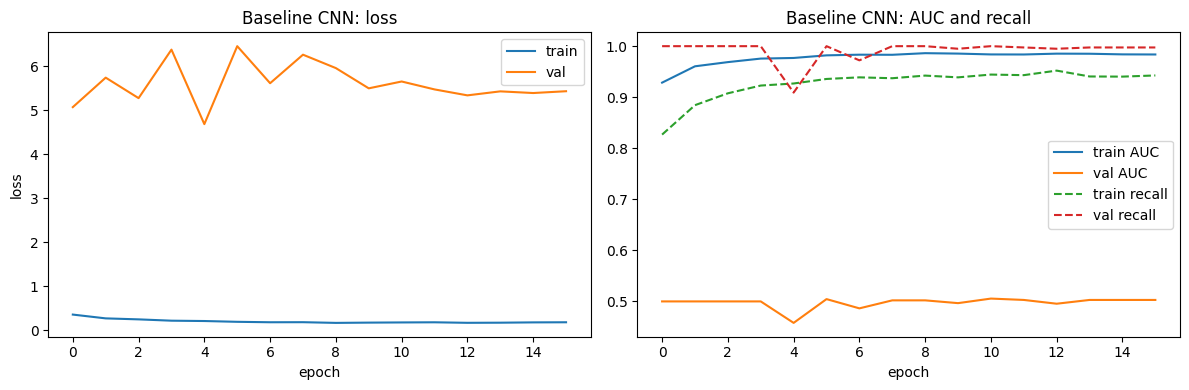

In [ ]:
hist_df = pd.DataFrame(history.history)
hist_df.to_csv(REPORTS_DIR / "baseline_history.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_df["loss"], label="train")
axes[0].plot(hist_df["val_loss"], label="val")
axes[0].set_title("Baseline CNN: loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()

axes[1].plot(hist_df["auc"], label="train AUC")
axes[1].plot(hist_df["val_auc"], label="val AUC")
axes[1].plot(hist_df["recall"], label="train recall", linestyle="--")
axes[1].plot(hist_df["val_recall"], label="val recall", linestyle="--")
axes[1].set_title("Baseline CNN: AUC and recall")
axes[1].set_xlabel("epoch"); axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "baseline_training_curves.png", bbox_inches="tight")
plt.show()

## 4. Test set evaluation

Quick numbers here. The full evaluation (confusion matrix, ROC, PR, threshold tuning, Grad-CAM) lives in `05_evaluation_gradcam.ipynb`, where the baseline and the transfer-learning model are compared head to head.

In [ ]:
test_metrics = model.evaluate(test_ds, return_dict=True, verbose=1)
test_metrics = {k: float(v) for k, v in test_metrics.items()}
test_metrics

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 265ms/step - accuracy: 0.6266 - auc: 0.5128 - loss: 8.3011 - precision: 0.6260 - recall: 1.0000


{'accuracy': 0.6266025900840759,
 'auc': 0.5128204822540283,
 'loss': 8.301064491271973,
 'precision': 0.6260032057762146,
 'recall': 1.0}

In [ ]:
metrics_path = REPORTS_DIR / "baseline_test_metrics.json"
metrics_path.write_text(json.dumps(test_metrics, indent=2))
print("Saved metrics to", metrics_path)
print("Saved checkpoint to", ckpt_path)

Saved metrics to /content/reports/baseline_test_metrics.json
Saved checkpoint to /content/models/baseline_cnn.keras


In [ ]:
# === Backup ke Drive ===
import shutil
from pathlib import Path
OUT = Path('/content/drive/MyDrive/pneumonia-project/outputs')
OUT.mkdir(exist_ok=True)
for src in [Path('/content/models'), Path('/content/reports')]:
    dst = OUT / src.name
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
print('Backup OK ->', OUT)

Backup OK -> /content/drive/MyDrive/pneumonia-project/outputs


In [17]:
from src.model_builder import build_densenet121, unfreeze_top_layers

model = build_densenet121()
trainable_params = sum(np.prod(v.shape) for v in model.trainable_weights)
total_params = model.count_params()
print(f"Total params:     {total_params:,}")
print(f"Trainable (head): {trainable_params:,}")

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total params:     7,168,833
Trainable (head): 131,329


In [18]:
stage1_ckpt = str(MODELS_DIR / "densenet_stage1.keras")
stage1_callbacks = standard_callbacks(stage1_ckpt, patience=4)

history_stage1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=stage1_callbacks,
    verbose=1,
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 634ms/step - accuracy: 0.7936 - auc: 0.8885 - loss: 0.4094 - precision: 0.9215 - recall: 0.7821
Epoch 1: val_auc improved from None to 0.97338, saving model to /content/models/densenet_stage1.keras

Epoch 1: finished saving model to /content/models/densenet_stage1.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 162s 852ms/step - accuracy: 0.8611 - auc: 0.9421 - loss: 0.3085 - precision: 0.9501 - recall: 0.8580 - val_accuracy: 0.9238 - val_auc: 0.9734 - val_loss: 0.1875 - val_precision: 0.9361 - val_recall: 0.9621 - learning_rate: 0.0010
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9038 - auc: 0.9647 - loss: 0.2410 - precision: 0.9617 - recall: 0.9064
Epoch 2: val_auc improved from 0.97338 to 0.97344, saving model to /content/models/densenet_stage1.keras

Epoch 2: finished saving model to /content/models/densenet_stage1.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 92s 619ms/step - accuracy: 0.9046 - auc: 0.9668 - loss: 0.2329 - precision: 0.966

In [21]:
model = unfreeze_top_layers(model, num_layers=30, learning_rate=1e-5)
trainable_params = sum(np.prod(v.shape) for v in model.trainable_weights)
print(f"Trainable params after unfreezing: {trainable_params:,}")

Trainable params after unfreezing: 772,737


In [22]:
best_ckpt = str(MODELS_DIR / "best_model.keras")
stage2_callbacks = standard_callbacks(best_ckpt, patience=5)

history_stage2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weights,
    callbacks=stage2_callbacks,
    verbose=1,
)

Epoch 1/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.9245 - auc: 0.9689 - loss: 0.2474 - precision: 0.9554 - recall: 0.9430
Epoch 1: val_auc improved from None to 0.97694, saving model to /content/models/best_model.keras

Epoch 1: finished saving model to /content/models/best_model.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 171s 883ms/step - accuracy: 0.9276 - auc: 0.9738 - loss: 0.2213 - precision: 0.9600 - recall: 0.9418 - val_accuracy: 0.9145 - val_auc: 0.9769 - val_loss: 0.1939 - val_precision: 0.9147 - val_recall: 0.9747 - learning_rate: 1.0000e-05
Epoch 2/15
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.9248 - auc: 0.9747 - loss: 0.2080 - precision: 0.9676 - recall: 0.9292
Epoch 2: val_auc did not improve from 0.97694
147/147 ━━━━━━━━━━━━━━━━━━━━ 86s 579ms/step - accuracy: 0.9237 - auc: 0.9750 - loss: 0.2022 - precision: 0.9719 - recall: 0.9240 - val_accuracy: 0.9201 - val_auc: 0.9764 - val_loss: 0.1847 - val_precision: 0.9274 - val_recall: 0.9672 - learning_rat

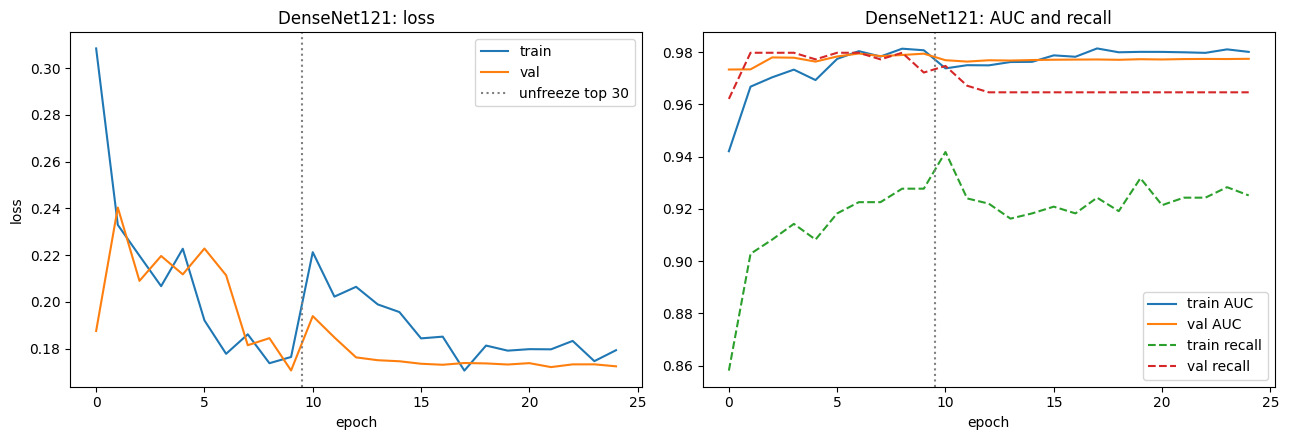

In [23]:
h1 = pd.DataFrame(history_stage1.history).assign(stage="stage1_features")
h2 = pd.DataFrame(history_stage2.history).assign(stage="stage2_finetune")
h2.index = h2.index + len(h1)
hist = pd.concat([h1, h2])
hist.to_csv(REPORTS_DIR / "densenet_history.csv", index=False)

boundary = len(h1) - 0.5
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(hist.index, hist["loss"], label="train")
axes[0].plot(hist.index, hist["val_loss"], label="val")
axes[0].axvline(boundary, color="gray", linestyle=":", label="unfreeze top 30")
axes[0].set_title("DenseNet121: loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()

axes[1].plot(hist.index, hist["auc"], label="train AUC")
axes[1].plot(hist.index, hist["val_auc"], label="val AUC")
axes[1].plot(hist.index, hist["recall"], label="train recall", linestyle="--")
axes[1].plot(hist.index, hist["val_recall"], label="val recall", linestyle="--")
axes[1].axvline(boundary, color="gray", linestyle=":")
axes[1].set_title("DenseNet121: AUC and recall")
axes[1].set_xlabel("epoch"); axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "densenet_training_curves.png", bbox_inches="tight")
plt.show()

In [24]:
best = tf.keras.models.load_model(best_ckpt)
test_metrics = best.evaluate(test_ds, return_dict=True, verbose=1)
test_metrics = {k: float(v) for k, v in test_metrics.items()}
(REPORTS_DIR / "densenet_test_metrics.json").write_text(json.dumps(test_metrics,
indent=2))
print(test_metrics)
print("Best model saved at:", best_ckpt)

20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 796ms/step - accuracy: 0.7580 - auc: 0.9019 - loss: 0.6857 - precision: 0.7276 - recall: 0.9795
{'accuracy': 0.7580128312110901, 'auc': 0.9018956422805786, 'loss': 0.6857421398162842, 'precision': 0.7276190519332886, 'recall': 0.9794871807098389}
Best model saved at: /content/models/best_model.keras


In [25]:
import shutil
from pathlib import Path
OUT = Path('/content/drive/MyDrive/pneumonia-project/outputs')
OUT.mkdir(exist_ok=True)
for src in [Path('/content/models'), Path('/content/reports')]:
    dst = OUT / src.name
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)
print('Backup OK ->', OUT)

Backup OK -> /content/drive/MyDrive/pneumonia-project/outputs
